# Raidium Challenge 2025 — Pre-trained Model Comparison (GPU)

**Environment:** Google Colab + T4 GPU  
**Before running:** `Runtime → Change runtime type → T4 GPU → Save`

Four pre-trained encoder models, all using the same two-phase training strategy:

| # | Model | Encoder | Decoder | Pre-training |
|---|---|---|---|---|
| 1 | **ResNet-50 U-Net** | ResNet-50 | U-Net | ImageNet |
| 2 | **EfficientNet-B4 U-Net** | EfficientNet-B4 | U-Net | ImageNet |
| 3 | **ResNet-50 U-Net++** | ResNet-50 | U-Net++ (nested skips) | ImageNet |
| 4 | **MiT-B2 U-Net** | Mix Transformer B2 | U-Net | ImageNet |

---
## Table of Contents
1. [Mount Google Drive & Extract Data](#setup)
2. [Imports & Config](#imports)
3. [Load Data](#data)
4. [Dataset & DataLoader](#dataset)
5. [Model Definitions](#models)
6. [Loss, Optimiser & Training Loop](#training)
7. [Train All Models](#train-all)
8. [Evaluation & Comparison](#evaluation)
9. [Submission](#submission)


## 1. Mount Google Drive & Extract Data <a id='setup'></a>

In [1]:
from google.colab import drive
import shutil, zipfile
from pathlib import Path

drive.mount('/content/drive')

DRIVE_DIR = Path("/content/drive/MyDrive/raidium")
LOCAL_DIR = Path("/content/raidium")
LOCAL_DIR.mkdir(exist_ok=True)

for filename in ["y_train.csv", "annotated_labels.json"]:
    src = DRIVE_DIR / filename
    dst = LOCAL_DIR / filename
    if not dst.exists():
        print(f"Copying {filename} …")
        shutil.copy(str(src), str(dst))
    else:
        print(f"{filename} already present, skipping.")

for zip_name, extract_check in [
    ("x_train.zip", LOCAL_DIR / "train-images"),
    ("x_test.zip",  LOCAL_DIR / "test-images"),
]:
    if extract_check.exists():
        print(f"{zip_name} already extracted, skipping.")
    else:
        zip_src = DRIVE_DIR / zip_name
        zip_dst = LOCAL_DIR / zip_name
        print(f"Copying {zip_name} from Drive …")
        shutil.copy(str(zip_src), str(zip_dst))
        print(f"Extracting {zip_name} …")
        with zipfile.ZipFile(str(zip_dst), "r") as zf:
            zf.extractall(str(LOCAL_DIR))
        zip_dst.unlink()
        print("Done.")

train_img_dir = LOCAL_DIR / "train-images"
test_img_dir  = LOCAL_DIR / "test-images"
print(f"\nTrain images : {len(list(train_img_dir.glob('*.png')))}")
print(f"Test  images : {len(list(test_img_dir.glob('*.png')))}")
print(f"Label CSV    : {(LOCAL_DIR / 'y_train.csv').exists()}")


Mounted at /content/drive
Copying y_train.csv …
Copying annotated_labels.json …
Copying x_train.zip from Drive …
Extracting x_train.zip …
Done.
Copying x_test.zip from Drive …
Extracting x_test.zip …
Done.

Train images : 2000
Test  images : 500
Label CSV    : True


## 2. Imports & Config <a id='imports'></a>

In [2]:
!pip install segmentation-models-pytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 15.2 MB/s eta 0:00:00


In [3]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

print(f"PyTorch : {torch.__version__}")
print(f"SMP     : {smp.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch : 2.11.0+cu128
SMP     : 0.5.0
CUDA    : True
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
LOCAL_DIR     = Path("/content/raidium")
TRAIN_IMG_DIR = LOCAL_DIR / "train-images"
TEST_IMG_DIR  = LOCAL_DIR / "test-images"
LABEL_CSV     = LOCAL_DIR / "y_train.csv"

# ── Segmentation ──────────────────────────────────────────────────────────────
NUM_CLASSES = 54
NUM_OUTPUTS = NUM_CLASSES + 1

# ── Training ──────────────────────────────────────────────────────────────────
IMG_SIZE      = 256
VAL_SPLIT     = 200
BATCH_SIZE    = 8       # safe for T4 at 256×256; lower to 4 if OOM
LR            = 3e-4
SEED          = 42
EPOCHS        = 30      # used for all four models
FREEZE_EPOCHS = 5       # Phase 1: encoder frozen

torch.manual_seed(SEED)
np.random.seed(SEED)
print("Config ready.")


Config ready.


## 3. Load Data <a id='data'></a>

In [5]:
def load_images(image_dir: Path) -> np.ndarray:
    """Load PNG images in strict numerical order → (N, H, W) uint8 array."""
    files = sorted(Path(image_dir).glob("*.png"), key=lambda p: int(p.stem))
    if not files:
        raise FileNotFoundError(f"No PNG files in {image_dir}")
    imgs = [np.array(Image.open(f).convert("L")) for f in tqdm(files, desc=image_dir.name)]
    return np.stack(imgs, axis=0)

print("Loading training images …")
data_train = load_images(TRAIN_IMG_DIR)
print("Loading test images …")
data_test  = load_images(TEST_IMG_DIR)

IMG_H, IMG_W = data_train.shape[1], data_train.shape[2]
print(f"\nTrain : {data_train.shape}  (N×H×W)")
print(f"Test  : {data_test.shape}")
print(f"Resolution : {IMG_H}×{IMG_W}")


Loading training images …


train-images: 100%|██████████| 2000/2000 [00:02<00:00, 904.68it/s]


Loading test images …


test-images: 100%|██████████| 500/500 [00:00<00:00, 805.03it/s]


Train : (2000, 256, 256)  (N×H×W)
Test  : (500, 256, 256)
Resolution : 256×256


In [6]:
print("Loading labels (may take ~30 s) …")
labels_train = pd.read_csv(LABEL_CSV, index_col=0).T
print(f"Labels shape : {labels_train.shape}")

assert labels_train.shape[1] == IMG_H * IMG_W, (
    f"Label columns ({labels_train.shape[1]}) != image area "
    f"({IMG_H}×{IMG_W}={IMG_H*IMG_W})"
)
print(f"Unique label values (sample): {np.unique(labels_train.values[:3])}")


Loading labels (may take ~30 s) …
Labels shape : (2000, 65536)
Unique label values (sample): [ 0  4 10 12 18 23 24 28 30 31 32 33 44 47 53]


In [7]:
masks_np = labels_train.values.reshape(-1, IMG_H, IMG_W).astype(np.int64)

val_imgs    = data_train[:VAL_SPLIT]
val_masks   = masks_np[:VAL_SPLIT]
train_imgs  = data_train[VAL_SPLIT:]
train_masks = masks_np[VAL_SPLIT:]

print(f"Train : {train_imgs.shape[0]} images")
print(f"Val   : {val_imgs.shape[0]} images")


Train : 1800 images
Val   : 200 images


In [8]:
class_counts  = np.bincount(train_masks.ravel(), minlength=NUM_OUTPUTS).astype(np.float64)
class_counts[0] /= 10
class_weights   = 1.0 / (class_counts + 1)
class_weights   = class_weights / class_weights.sum() * NUM_OUTPUTS
weight_tensor   = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights computed. Min={weight_tensor.min():.4f}  Max={weight_tensor.max():.4f}")


Class weights computed. Min=0.0006  Max=13.5847


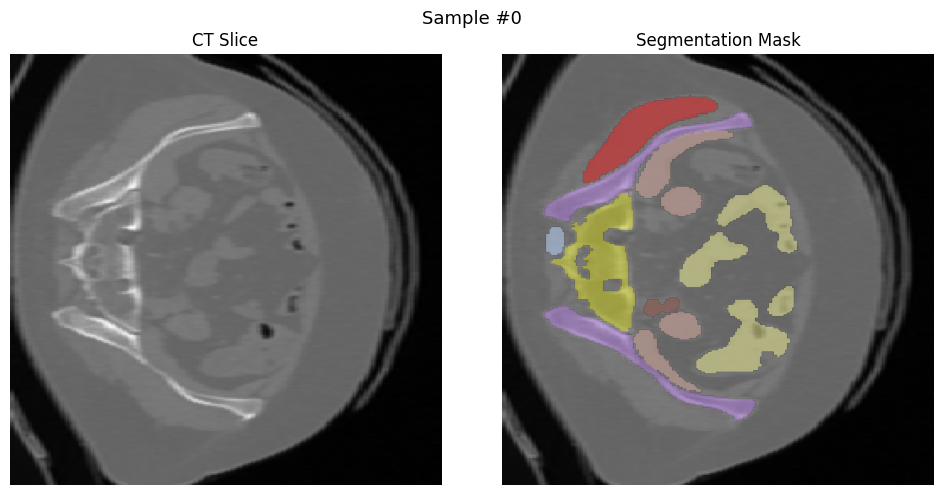

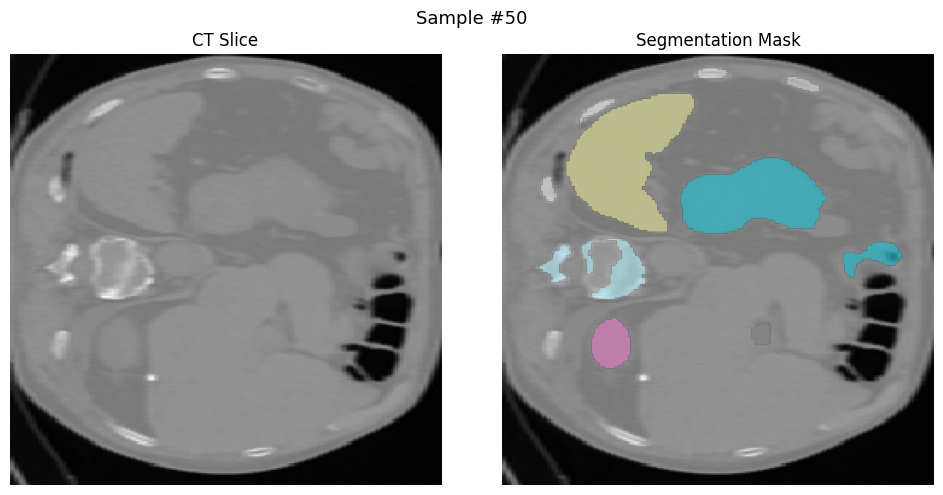

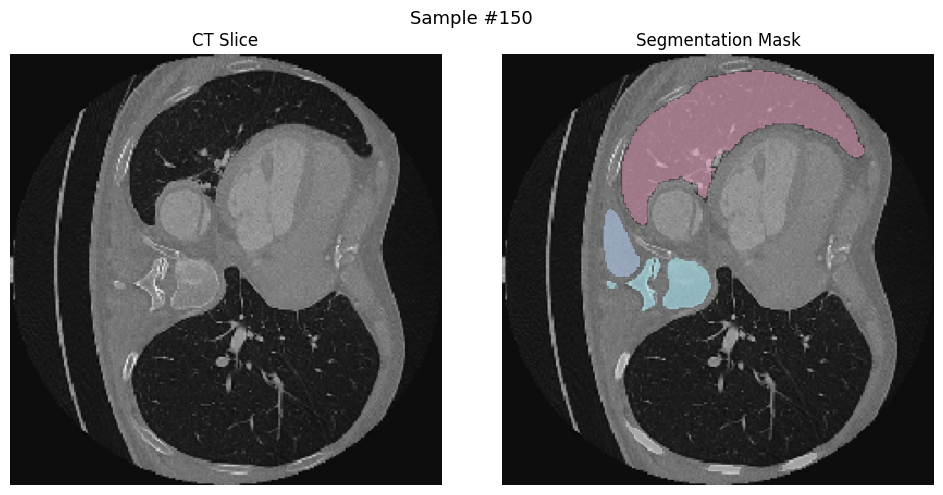

In [9]:
def plot_sample(image, mask, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image, cmap="gray"); axes[0].set_title("CT Slice"); axes[0].axis("off")
    overlay = np.ma.masked_where(mask == 0, mask)
    axes[1].imshow(image, cmap="gray")
    axes[1].imshow(overlay, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    axes[1].set_title("Segmentation Mask"); axes[1].axis("off")
    if title: fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

for idx in [0, 50, 150]:
    plot_sample(data_train[idx], masks_np[idx], title=f"Sample #{idx}")


## 4. Dataset & DataLoader <a id='dataset'></a>

In [10]:
class CTSegDatasetRGB(Dataset):
    """
    All four pre-trained encoders expect 3-channel RGB input with ImageNet
    mean/std normalisation. Grayscale CT → replicate to (3,H,W) → normalise.

    ImageNet stats: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    """
    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __init__(self, images, masks, img_size=IMG_SIZE, augment=False):
        self.images   = images
        self.masks    = masks
        self.img_size = img_size
        self.augment  = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx].astype(np.float32) / 255.0).unsqueeze(0)
        msk = torch.from_numpy(self.masks[idx])

        img = F.interpolate(img.unsqueeze(0), size=self.img_size,
                            mode="bilinear", align_corners=False).squeeze(0)  # (1,S,S)
        msk = F.interpolate(msk.unsqueeze(0).unsqueeze(0).float(), size=self.img_size,
                            mode="nearest").squeeze().long()                  # (S,S)

        img3 = img.repeat(3, 1, 1)                   # (3,S,S)
        img3 = (img3 - self.MEAN) / self.STD          # ImageNet normalisation

        if self.augment:
            if torch.rand(1) > 0.5:
                img3 = TF.hflip(img3)
                msk  = TF.hflip(msk.unsqueeze(0)).squeeze(0)
            if torch.rand(1) > 0.5:
                img3 = TF.vflip(img3)
                msk  = TF.vflip(msk.unsqueeze(0)).squeeze(0)
            # brightness jitter in normalised space
            factor = 0.8 + 0.4 * torch.rand(1).item()
            img3   = torch.clamp(img3 * factor,
                                 -self.MEAN / self.STD,        # approx lower
                                 (1.0 - self.MEAN) / self.STD) # approx upper

        return img3, msk   # (3,S,S), (S,S)


_kw = dict(num_workers=2, pin_memory=True)
train_ds  = CTSegDatasetRGB(train_imgs, train_masks, augment=True)
val_ds    = CTSegDatasetRGB(val_imgs,   val_masks,   augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **_kw)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **_kw)

imgs_b, msks_b = next(iter(train_loader))
print(f"Batch — images: {imgs_b.shape}, masks: {msks_b.shape}")
assert imgs_b.shape[1] == 3  and msks_b.ndim == 3
print("Shape checks passed ✓")


Batch — images: torch.Size([8, 3, 256, 256]), masks: torch.Size([8, 256, 256])
Shape checks passed ✓


## 5. Model Definitions <a id='models'></a>

All four models are built with `segmentation_models_pytorch`.
Weights download automatically on first run (~50–200 MB each, cached in `/root/.cache`).

| Model | Why it's interesting |
|---|---|
| **ResNet-50 U-Net** | Strong CNN baseline; reference point from last notebook |
| **EfficientNet-B4 U-Net** | Compound-scaled CNN; better accuracy/param ratio than ResNet |
| **ResNet-50 U-Net++** | Same encoder as #1 but nested dense skip connections in decoder — isolates decoder impact |
| **MiT-B2 U-Net** | Transformer encoder; captures long-range context; helps thin/tubular organs |


In [11]:
# Each entry: (display_name, smp_class, encoder_name, encoder_weights, ckpt_filename)
MODEL_CONFIGS = [
    (
        "ResNet-50 U-Net",
        smp.Unet,
        "resnet50",
        "imagenet",
        "ckpt_resnet50_unet.pt",
    ),
    (
        "EfficientNet-B4 U-Net",
        smp.Unet,
        "efficientnet-b4",
        "imagenet",
        "ckpt_effb4_unet.pt",
    ),
    (
        "ResNet-50 U-Net++",
        smp.UnetPlusPlus,
        "resnet50",
        "imagenet",
        "ckpt_resnet50_unetpp.pt",
    ),
    (
        "MiT-B2 U-Net",
        smp.Unet,
        "mit_b2",
        "imagenet",
        "ckpt_mitb2_unet.pt",
    ),
]


def build_model(smp_class, encoder_name, encoder_weights):
    """Instantiate an smp segmentation model and move it to DEVICE."""
    model = smp_class(
        encoder_name    = encoder_name,
        encoder_weights = encoder_weights,
        in_channels     = 3,
        classes         = NUM_OUTPUTS,
        activation      = None,
    )
    return model.to(DEVICE)


# ── Smoke test all four ───────────────────────────────────────────────────────
dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
print("Model smoke tests:")
for name, cls, enc, wts, _ in MODEL_CONFIGS:
    m = build_model(cls, enc, wts)
    with torch.no_grad():
        out = m(dummy)
    total  = sum(p.numel() for p in m.parameters())
    enc_p  = sum(p.numel() for p in m.encoder.parameters())
    print(f"  {name:30s}  out={tuple(out.shape)}  "
          f"total={total/1e6:.1f}M  encoder={enc_p/1e6:.1f}M")
    del m
torch.cuda.empty_cache()


Model smoke tests:


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  ResNet-50 U-Net                 out=(1, 55, 256, 256)  total=32.5M  encoder=23.5M


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

  EfficientNet-B4 U-Net           out=(1, 55, 256, 256)  total=20.2M  encoder=17.5M
  ResNet-50 U-Net++               out=(1, 55, 256, 256)  total=49.0M  encoder=23.5M


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

  MiT-B2 U-Net                    out=(1, 55, 256, 256)  total=27.5M  encoder=24.2M


## 6. Loss, Optimiser & Training Loop <a id='training'></a>

In [12]:
class DiceLoss(nn.Module):
    """Memory-efficient soft Dice — iterates over classes, no full one-hot."""
    def __init__(self, num_classes=NUM_OUTPUTS, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        dice_sum, n_valid = 0.0, 0
        for cls in range(1, self.num_classes):
            p = probs[:, cls]
            g = (targets == cls).float()
            inter = (p * g).sum()
            card  = p.sum() + g.sum()
            if card > 0:
                dice_sum += (2.0 * inter + self.smooth) / (card + self.smooth)
                n_valid  += 1
        return 1.0 - dice_sum / max(n_valid, 1)


class CombinedLoss(nn.Module):
    """Class-weighted CE + soft Dice."""
    def __init__(self, ce_w=0.5, dice_w=0.5, class_weights=None):
        super().__init__()
        self.ce     = nn.CrossEntropyLoss(weight=class_weights)
        self.dice   = DiceLoss()
        self.ce_w   = ce_w
        self.dice_w = dice_w
    def forward(self, logits, targets):
        return self.ce_w * self.ce(logits, targets) + self.dice_w * self.dice(logits, targets)


loss_fn = CombinedLoss(ce_w=0.5, dice_w=0.5, class_weights=weight_tensor)
print("Loss function ready.")


Loss function ready.


In [13]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for imgs, masks in tqdm(loader, desc="train" if is_train else "val ", leave=False):
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            if is_train and scaler is not None:
                with torch.cuda.amp.autocast():
                    logits = model(imgs)
                    loss   = criterion(logits, masks)
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                    logits = model(imgs)
                    loss   = criterion(logits, masks)
                if is_train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


def train_pretrained(model, criterion, epochs, save_name,
                     lr_decoder=LR, lr_encoder=LR / 10,
                     freeze_epochs=FREEZE_EPOCHS):
    """
    Two-phase training for any smp model.

    Phase 1 (epochs 1–freeze_epochs):
        Encoder frozen → decoder + head only.
    Phase 2 (freeze_epochs+1–epochs):
        Encoder unfrozen with lr_encoder (10× lower) via separate param group.

    Works for both smp.Unet and smp.UnetPlusPlus since both expose .encoder,
    .decoder, and .segmentation_head attributes.
    """
    scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None
    best_val  = float("inf")
    history   = {"train": [], "val": [], "phase": []}
    ckpt_path = LOCAL_DIR / save_name
    optimizer = None
    scheduler = None

    for epoch in range(1, epochs + 1):

        # ── Phase 1 setup (once) ──────────────────────────────────────────────
        if epoch == 1:
            print(f"  [Phase 1] Encoder frozen for epochs 1–{freeze_epochs}")
            for p in model.encoder.parameters():
                p.requires_grad = False
            optimizer = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=lr_decoder, weight_decay=1e-4
            )

        # ── Phase 2 setup (once) ──────────────────────────────────────────────
        if epoch == freeze_epochs + 1:
            print(f"  [Phase 2] Encoder unfrozen — "
                  f"encoder lr={lr_encoder:.1e}, decoder lr={lr_decoder:.1e}")
            for p in model.encoder.parameters():
                p.requires_grad = True
            optimizer = torch.optim.AdamW([
                {"params": model.encoder.parameters(),          "lr": lr_encoder},
                {"params": model.decoder.parameters(),          "lr": lr_decoder},
                {"params": model.segmentation_head.parameters(),"lr": lr_decoder},
            ], weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs - freeze_epochs
            )

        phase = 1 if epoch <= freeze_epochs else 2
        tr  = run_epoch(train_loader, model, criterion, optimizer, scaler)
        val = run_epoch(val_loader,   model, criterion)
        if scheduler and phase == 2:
            scheduler.step()

        history["train"].append(tr)
        history["val"].append(val)
        history["phase"].append(phase)
        improved = val < best_val
        if improved:
            best_val = val
            torch.save(model.state_dict(), str(ckpt_path))
        print(f"  Epoch {epoch:3d}/{epochs}  [Ph{phase}]  "
              f"train={tr:.4f}  val={val:.4f}{'  ✓' if improved else ''}")

    print(f"  Best val loss: {best_val:.4f}  — {ckpt_path.name}")
    model.load_state_dict(torch.load(str(ckpt_path), map_location=DEVICE))
    return history


def plot_history(history, title):
    fig, ax = plt.subplots(figsize=(9, 4))
    epochs = range(1, len(history["train"]) + 1)
    ax.plot(epochs, history["train"], label="train loss")
    ax.plot(epochs, history["val"],   label="val loss")
    if "phase" in history:
        n_frozen = sum(1 for p in history["phase"] if p == 1)
        ax.axvspan(1, n_frozen + 0.5, alpha=0.08, color="orange",
                   label=f"Phase 1 — encoder frozen ({n_frozen} epochs)")
        ax.axvspan(n_frozen + 0.5, len(history["train"]) + 0.5,
                   alpha=0.08, color="green", label="Phase 2 — full fine-tune")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(title); ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

print("Training utilities ready.")


Training utilities ready.


## 7. Train All Models <a id='train-all'></a>

Each model is trained sequentially, deleted from GPU memory, then reloaded for evaluation. This keeps peak VRAM usage to one model at a time.


Training: ResNet-50 U-Net
  [Phase 1] Encoder frozen for epochs 1–5


  Epoch   1/30  [Ph1]  train=2.2679  val=2.3508  ✓


  Epoch   2/30  [Ph1]  train=1.9748  val=2.1298  ✓


  Epoch   3/30  [Ph1]  train=1.8164  val=2.0554  ✓


  Epoch   4/30  [Ph1]  train=1.7030  val=1.8082  ✓


...

  Epoch  26/30  [Ph2]  train=0.8837  val=1.1700


  Epoch  27/30  [Ph2]  train=0.8693  val=1.1560


  Epoch  28/30  [Ph2]  train=0.8624  val=1.1759


  Epoch  29/30  [Ph2]  train=0.8638  val=1.1876


  Epoch  30/30  [Ph2]  train=0.8572  val=1.1693
  Best val loss: 1.1467  — ckpt_resnet50_unet.pt


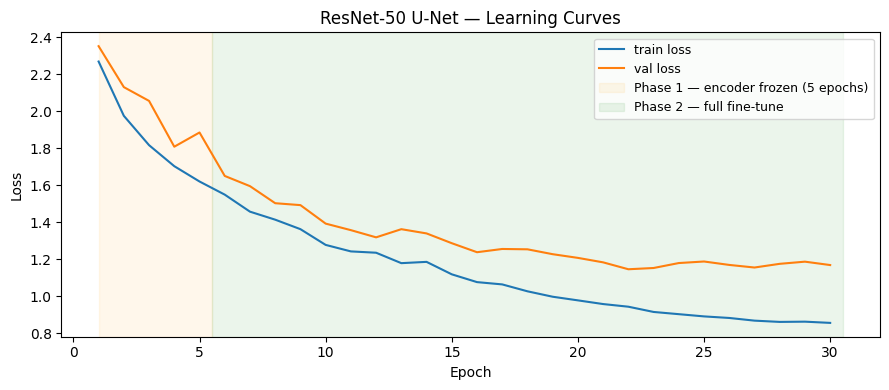

  GPU memory freed.

Training: EfficientNet-B4 U-Net
  [Phase 1] Encoder frozen for epochs 1–5


  Epoch   1/30  [Ph1]  train=2.2564  val=2.3075  ✓


  Epoch   2/30  [Ph1]  train=1.9692  val=2.0903  ✓


  Epoch   3/30  [Ph1]  train=1.7820  val=1.9231  ✓


  Epoch   4/30  [Ph1]  train=1.6976  val=1.8465  ✓


...

  Epoch  26/30  [Ph2]  train=0.9151  val=1.2089


  Epoch  27/30  [Ph2]  train=0.9193  val=1.2158


  Epoch  28/30  [Ph2]  train=0.9066  val=1.2194


  Epoch  29/30  [Ph2]  train=0.9033  val=1.2216


  Epoch  30/30  [Ph2]  train=0.9006  val=1.2112
  Best val loss: 1.2011  — ckpt_effb4_unet.pt


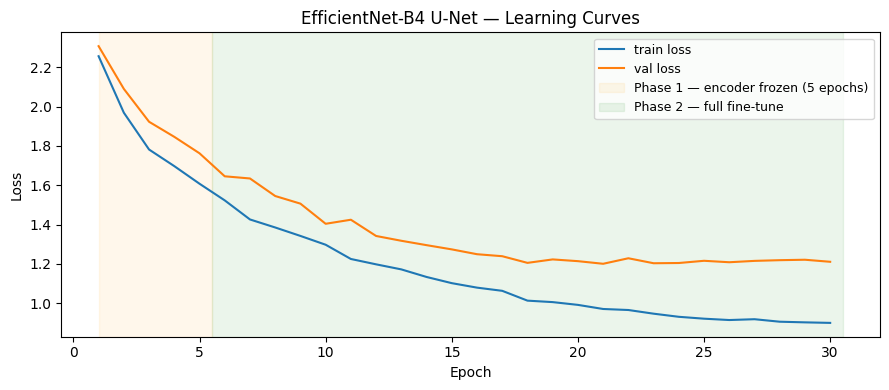

  GPU memory freed.

Training: ResNet-50 U-Net++
  [Phase 1] Encoder frozen for epochs 1–5


  Epoch   1/30  [Ph1]  train=2.2433  val=2.2024  ✓


  Epoch   2/30  [Ph1]  train=1.8626  val=2.0047  ✓


  Epoch   3/30  [Ph1]  train=1.6832  val=1.7788  ✓


  Epoch   4/30  [Ph1]  train=1.5424  val=1.6615  ✓


...

  Epoch  26/30  [Ph2]  train=0.7912  val=1.1762


  Epoch  27/30  [Ph2]  train=0.7845  val=1.1983


  Epoch  28/30  [Ph2]  train=0.7833  val=1.2072


  Epoch  29/30  [Ph2]  train=0.7773  val=1.2402


  Epoch  30/30  [Ph2]  train=0.7769  val=1.2042
  Best val loss: 1.1420  — ckpt_resnet50_unetpp.pt


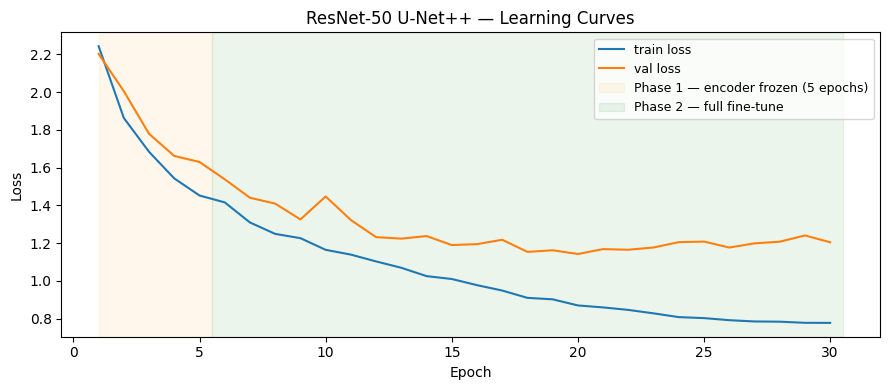

  GPU memory freed.

Training: MiT-B2 U-Net
  [Phase 1] Encoder frozen for epochs 1–5


  Epoch   1/30  [Ph1]  train=2.2770  val=2.2675  ✓


  Epoch   2/30  [Ph1]  train=1.9951  val=2.1543  ✓


  Epoch   3/30  [Ph1]  train=1.8575  val=2.0478  ✓


  Epoch   4/30  [Ph1]  train=1.7995  val=1.9653  ✓


...

  Epoch  26/30  [Ph2]  train=0.8729  val=1.1683


  Epoch  27/30  [Ph2]  train=0.8611  val=1.1625


  Epoch  28/30  [Ph2]  train=0.8578  val=1.1807


  Epoch  29/30  [Ph2]  train=0.8553  val=1.1625


  Epoch  30/30  [Ph2]  train=0.8544  val=1.1648
  Best val loss: 1.1279  — ckpt_mitb2_unet.pt


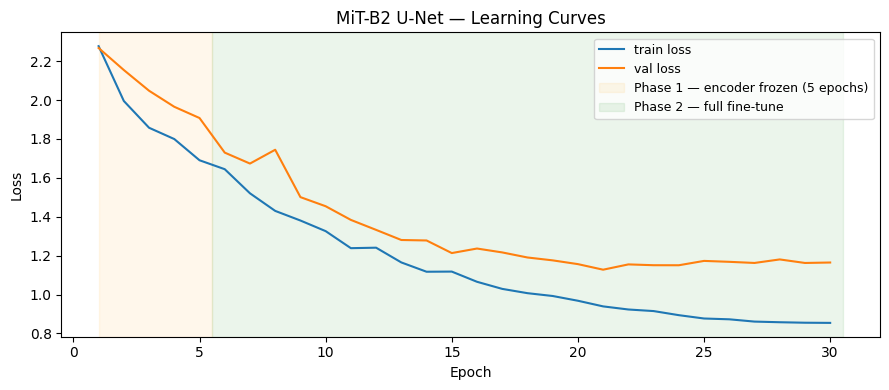

  GPU memory freed.

All models trained ✓


In [14]:
# histories dict — populated as each model finishes
histories = {}

for name, smp_cls, enc_name, enc_wts, ckpt_name in MODEL_CONFIGS:
    print("\n" + "=" * 65)
    print(f"Training: {name}")
    print("=" * 65)

    model = build_model(smp_cls, enc_name, enc_wts)
    hist  = train_pretrained(model, loss_fn, EPOCHS, ckpt_name)
    histories[name] = hist
    plot_history(hist, f"{name} — Learning Curves")

    # free GPU memory before next model
    del model
    torch.cuda.empty_cache()
    print(f"  GPU memory freed.")

print("\nAll models trained ✓")


## 8. Evaluation & Comparison <a id='evaluation'></a>

In [15]:
def dice_image(prediction, ground_truth):
    intersection = np.sum(prediction * ground_truth)
    if np.sum(prediction) == 0 and np.sum(ground_truth) == 0:
        return np.nan
    return 2 * intersection / (np.sum(prediction) + np.sum(ground_truth))

def dice_multiclass(prediction, ground_truth):
    return np.array([
        dice_image(prediction == i, ground_truth == i)
        for i in range(1, NUM_CLASSES + 1)
    ])

def dice_pandas(y_true_df, y_pred_df):
    y_pred = y_pred_df.T
    y_true = y_true_df.T
    scores = [
        dice_multiclass(y_true.values[i].ravel(), y_pred.values[i].ravel())
        for i in range(y_true.values.shape[0])
    ]
    final = np.stack(scores)
    return float(np.nanmean(np.nanmean(final, axis=0))), np.nanmean(final, axis=0)


In [16]:
MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
STD_T  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)

def predict_dataset(images, model, batch_size=BATCH_SIZE):
    """Run inference → DataFrame (N, H*W). All models use the RGB path."""
    model.eval()
    all_preds = []
    for start in tqdm(range(0, len(images), batch_size), desc="Predicting", leave=False):
        batch = images[start : start + batch_size]
        t = torch.from_numpy(batch.astype(np.float32) / 255.0).unsqueeze(1)
        t = F.interpolate(t, size=IMG_SIZE, mode="bilinear", align_corners=False)
        t = t.repeat(1, 3, 1, 1)
        t = (t.to(DEVICE) - MEAN_T) / STD_T
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            preds = model(t).argmax(dim=1, keepdim=True).float()
        preds = F.interpolate(preds, size=(IMG_H, IMG_W), mode="nearest")
        preds = preds.squeeze(1).cpu().numpy().astype(np.int32)
        all_preds.append(preds.reshape(len(batch), -1))
    return pd.DataFrame(np.concatenate(all_preds, axis=0))


In [17]:
labels_val_df = labels_train.iloc[:VAL_SPLIT]
results = {}

print("Evaluating models on validation set …")
for name, smp_cls, enc_name, enc_wts, ckpt_name in MODEL_CONFIGS:
    # reload best checkpoint for this model
    model = build_model(smp_cls, enc_name, enc_wts)
    model.load_state_dict(torch.load(str(LOCAL_DIR / ckpt_name), map_location=DEVICE))

    preds_df = predict_dataset(val_imgs, model)
    overall, per_class = dice_pandas(labels_val_df, preds_df)
    results[name] = {"overall": overall, "per_class": per_class, "preds_df": preds_df}
    print(f"  {name:30s}  Dice = {overall:.6f}")

    del model
    torch.cuda.empty_cache()

print("\nWatershed baseline Dice ≈ 0.0011")


Evaluating models on validation set …


  ResNet-50 U-Net                 Dice = 0.112173


  EfficientNet-B4 U-Net           Dice = 0.093427


  ResNet-50 U-Net++               Dice = 0.119428


  MiT-B2 U-Net                    Dice = 0.120373

Watershed baseline Dice ≈ 0.0011


In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = {"Watershed (baseline)": {"Overall Dice": 0.0011, "vs baseline": "1.0×",
                                  "Encoder": "—", "Decoder": "—"}}
decoder_map = {
    "ResNet-50 U-Net":       "U-Net",
    "EfficientNet-B4 U-Net": "U-Net",
    "ResNet-50 U-Net++":     "U-Net++",
    "MiT-B2 U-Net":          "U-Net",
}
encoder_map = {
    "ResNet-50 U-Net":       "ResNet-50",
    "EfficientNet-B4 U-Net": "EfficientNet-B4",
    "ResNet-50 U-Net++":     "ResNet-50",
    "MiT-B2 U-Net":          "MiT-B2",
}
for name, r in results.items():
    rows[name] = {
        "Overall Dice": round(r["overall"], 6),
        "vs baseline":  f"{r['overall'] / 0.0011:.1f}×",
        "Encoder":      encoder_map[name],
        "Decoder":      decoder_map[name],
    }
summary = pd.DataFrame(rows).T
print("\n=== Model comparison ===")
print(summary.to_string())



=== Model comparison ===
                      Overall Dice vs baseline          Encoder  Decoder
Watershed (baseline)        0.0011        1.0×                —        —
ResNet-50 U-Net           0.112173      102.0×        ResNet-50    U-Net
EfficientNet-B4 U-Net     0.093427       84.9×  EfficientNet-B4    U-Net
ResNet-50 U-Net++         0.119428      108.6×        ResNet-50  U-Net++
MiT-B2 U-Net              0.120373      109.4×           MiT-B2    U-Net


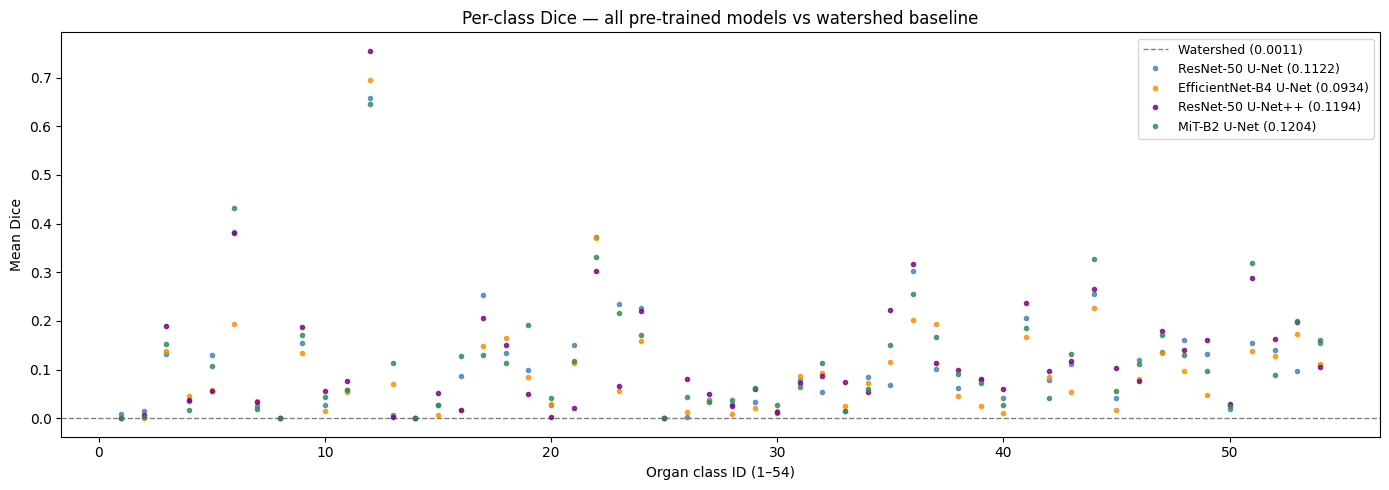

In [19]:
# ── Per-class Dice plot ───────────────────────────────────────────────────────
classes = np.arange(1, NUM_CLASSES + 1)
palette = {
    "ResNet-50 U-Net":       "steelblue",
    "EfficientNet-B4 U-Net": "darkorange",
    "ResNet-50 U-Net++":     "purple",
    "MiT-B2 U-Net":          "seagreen",
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0.0011, color="gray", linestyle="--", linewidth=1, label="Watershed (0.0011)")
for name, color in palette.items():
    if name in results:
        ax.plot(classes, results[name]["per_class"], "o", markersize=3,
                color=color, alpha=0.8,
                label=f"{name} ({results[name]['overall']:.4f})")
ax.set_xlabel("Organ class ID (1–54)"); ax.set_ylabel("Mean Dice")
ax.set_title("Per-class Dice — all pre-trained models vs watershed baseline")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


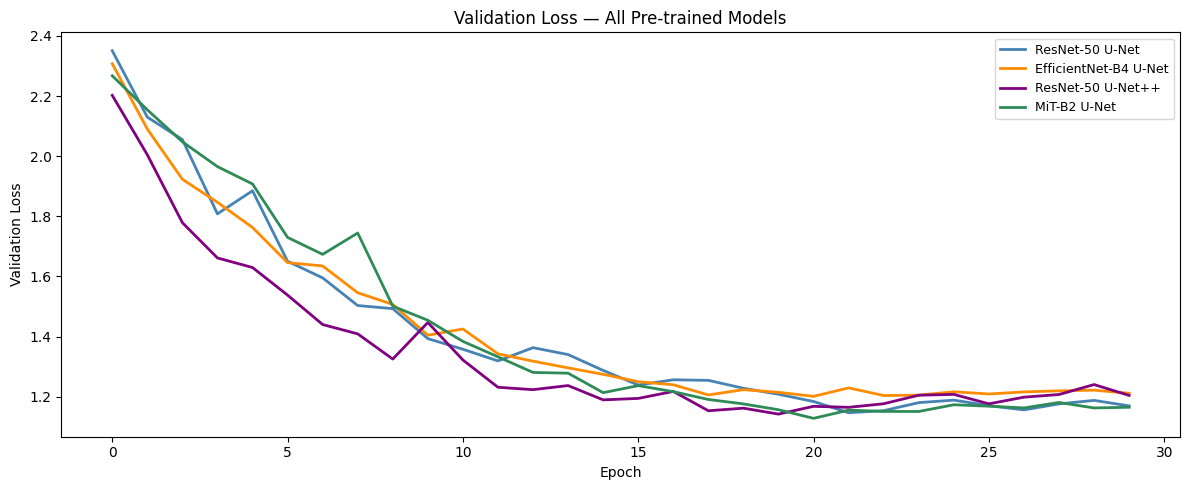

In [20]:
# ── Learning curves — all models on one plot ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for name, color in palette.items():
    if name in histories:
        h = histories[name]
        ax.plot(h["val"], color=color, linewidth=2, label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss — All Pre-trained Models")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


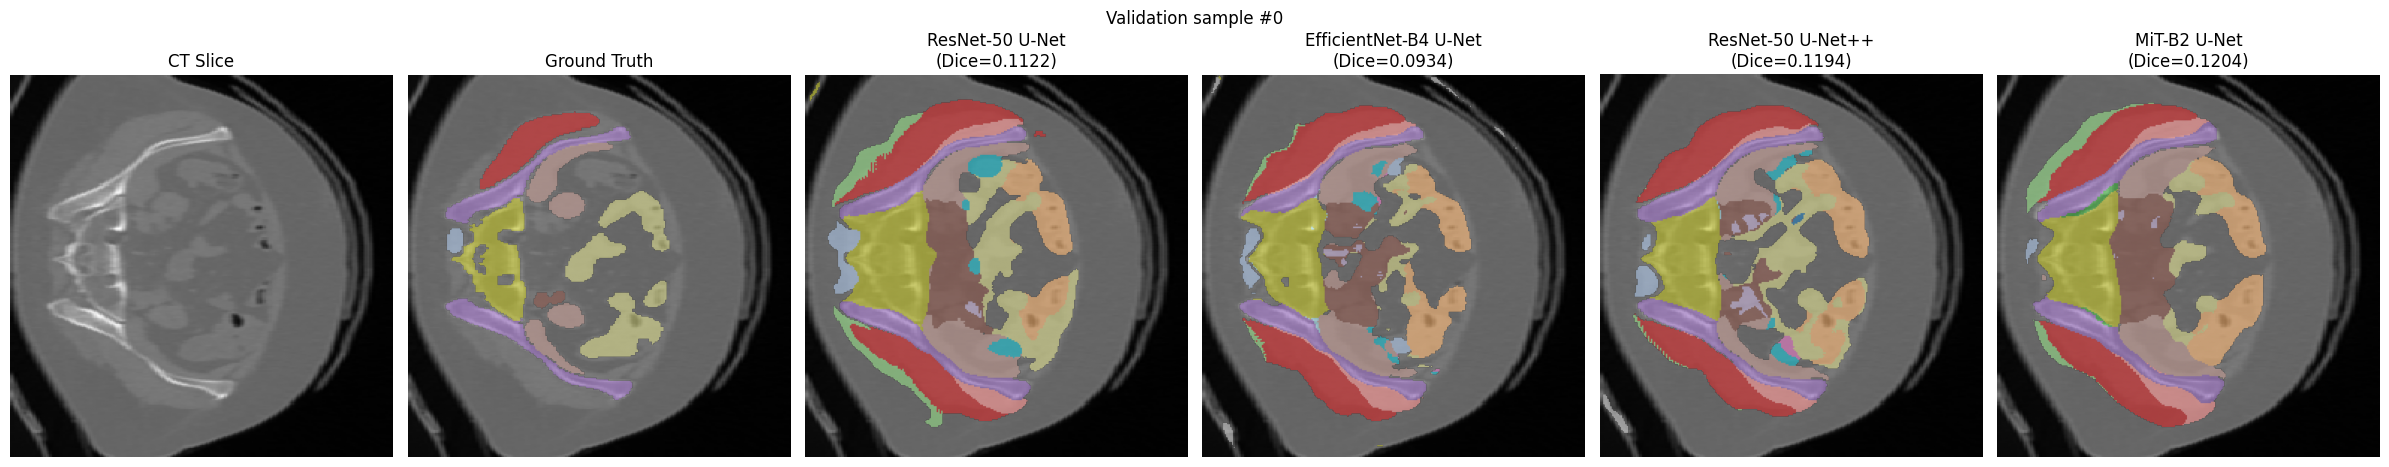

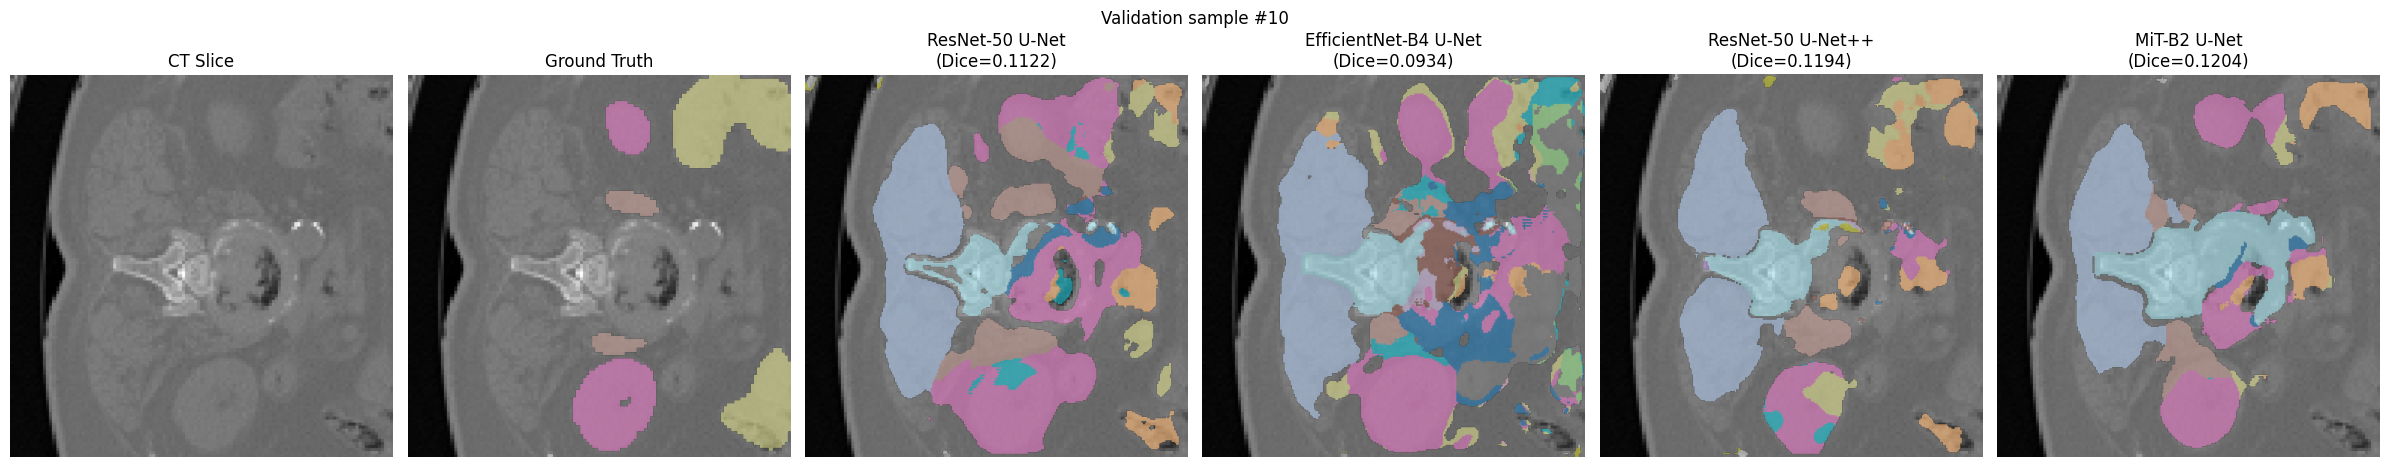

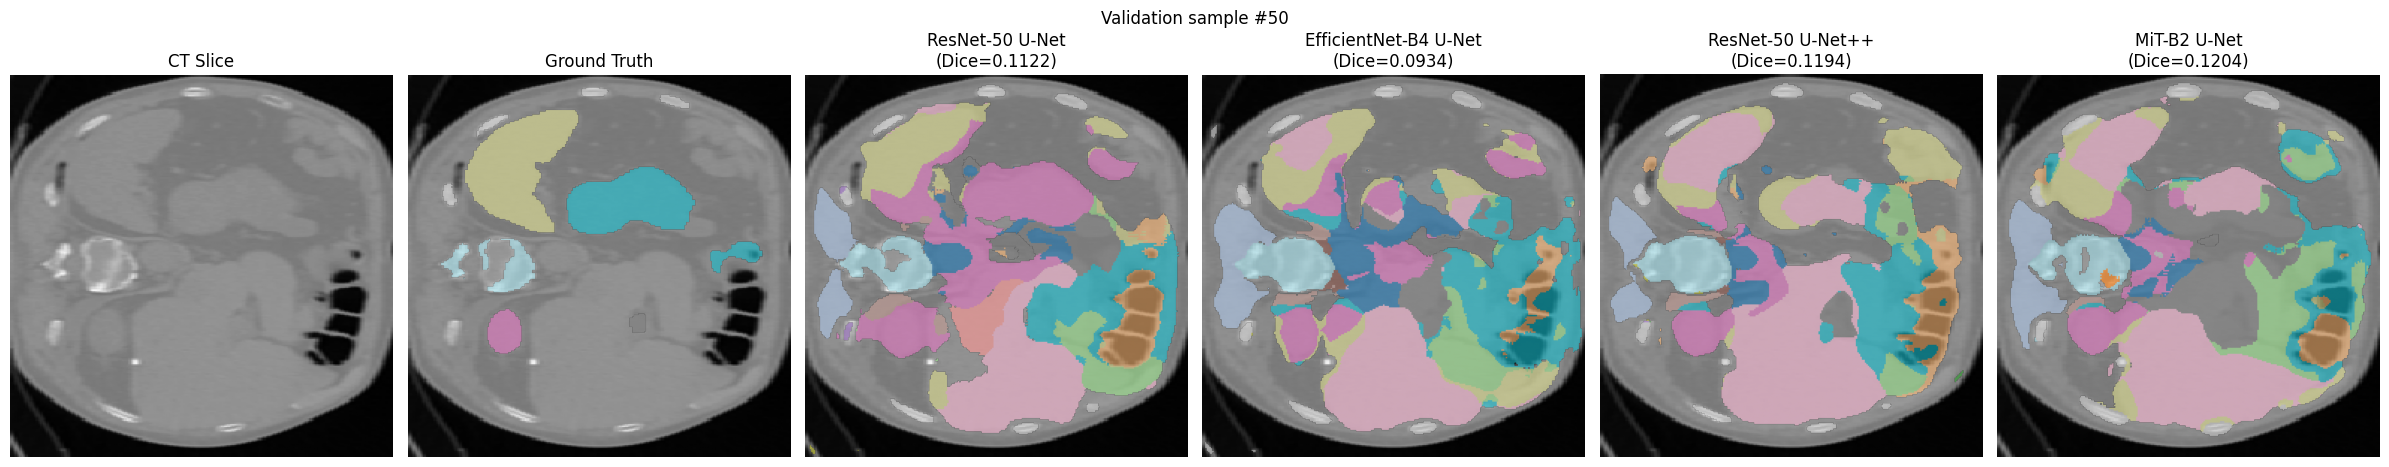

In [21]:
# ── Qualitative comparison (3 validation samples) ────────────────────────────
# Reload all models once for visual comparison
loaded_models = {}
for name, smp_cls, enc_name, enc_wts, ckpt_name in MODEL_CONFIGS:
    m = build_model(smp_cls, enc_name, enc_wts)
    m.load_state_dict(torch.load(str(LOCAL_DIR / ckpt_name), map_location=DEVICE))
    loaded_models[name] = m

sample_ids = [0, 10, 50]
for idx in sample_ids:
    n_cols = 2 + len(results)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5))

    axes[0].imshow(val_imgs[idx], cmap="gray")
    axes[0].set_title("CT Slice"); axes[0].axis("off")

    gt = np.ma.masked_where(val_masks[idx] == 0, val_masks[idx])
    axes[1].imshow(val_imgs[idx], cmap="gray")
    axes[1].imshow(gt, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    axes[1].set_title("Ground Truth"); axes[1].axis("off")

    for col, (name, r) in enumerate(results.items(), start=2):
        pr_arr = r["preds_df"].values.reshape(VAL_SPLIT, IMG_H, IMG_W)
        pr = np.ma.masked_where(pr_arr[idx] == 0, pr_arr[idx])
        axes[col].imshow(val_imgs[idx], cmap="gray")
        axes[col].imshow(pr, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
        axes[col].set_title(f"{name}\n(Dice={r['overall']:.4f})")
        axes[col].axis("off")

    fig.suptitle(f"Validation sample #{idx}"); plt.tight_layout(); plt.show()

# free all
for m in loaded_models.values():
    del m
torch.cuda.empty_cache()


## 9. Submission <a id='submission'></a>

In [22]:
best_name = max(results, key=lambda k: results[k]["overall"])
best_cfg  = next(cfg for cfg in MODEL_CONFIGS if cfg[0] == best_name)

print(f"Best model : {best_name}  (Dice = {results[best_name]['overall']:.6f})")
print("Reloading best checkpoint and generating test predictions …")

best_model = build_model(best_cfg[1], best_cfg[2], best_cfg[3])
best_model.load_state_dict(torch.load(str(LOCAL_DIR / best_cfg[4]), map_location=DEVICE))

test_preds_df = predict_dataset(data_test, best_model)
submission    = test_preds_df.T
submission.to_csv("/content/raidium/y_pred.csv")
print(f"Saved → /content/raidium/y_pred.csv  (shape: {submission.shape})")

del best_model; torch.cuda.empty_cache()


Best model : MiT-B2 U-Net  (Dice = 0.120373)
Reloading best checkpoint and generating test predictions …


Saved → /content/raidium/y_pred.csv  (shape: (65536, 500))


In [23]:
import shutil
shutil.copy("/content/raidium/y_pred.csv", str(DRIVE_DIR / "y_pred.csv"))
for _, _, _, _, ckpt_name in MODEL_CONFIGS:
    src = LOCAL_DIR / ckpt_name
    if src.exists():
        shutil.copy(str(src), str(DRIVE_DIR / ckpt_name))
print("All checkpoints and submission saved to Google Drive.")


All checkpoints and submission saved to Google Drive.


---
## Possible Next Steps

1. **EfficientNet-B7** — `encoder_name="efficientnet-b7"`; more capacity, use batch size 4
2. **MiT-B4 / MiT-B5** — larger Mix Transformer variants; bigger step up from MiT-B2
3. **Test-Time Augmentation (TTA)** — average predictions over hflip/vflip/rotation copies
4. **Ensemble** — average softmax probability maps from the top-2 models before argmax
5. **512×512 resolution** — T4 handles it at batch size 4 with any of these encoders
